In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
plt.style.use(['science','notebook'])

In [2]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [3]:
# NB Thresholds for t-stat with 21-1 dof!
t_95 = 1.725
t_99 = 2.528

### t0 = 100, E = 20, k = 7

In [4]:
subjects = (['03CM','04ML','05NK','06AT','07YC','08RD','09NT','10EM','11AD','12AD',
             '13AB','14LS','15AC','16AG','17SM','18NB','19LS','20FC','21AB','22RT','23ST'])
channel_X = "P1"
channel_Y = "FC1"
E = 20
tau_e = 1
k = 7
t0 = 100
taus = np.arange(0,431)
alphas = np.linspace(0.,1.5,300)

info_imbalances_X_to_Y = np.zeros((len(subjects),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(subjects),len(taus),len(alphas)))
for i_sub, sub in enumerate(subjects):
    _, info_imbalances_X_to_Y[i_sub], info_imbalances_Y_to_X[i_sub] = (
        pickle.load(open(f"./pickles/II_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0}_E{E}_tauE{tau_e}_k{k}.p","rb"))
    )

# compute Imbalance Gains
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)

/tmp/ipykernel_4151/2134681228.py:5: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y / errors_X_to_Y) > t_99
/tmp/ipykernel_4151/2134681228.py:6: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X / errors_Y_to_X) > t_99


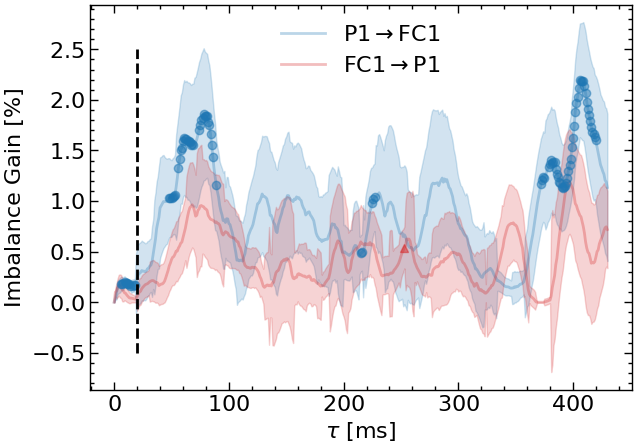

In [5]:
# plot results as a function of tau
fig, ax = plt.subplots(1,1,figsize=(7,5))
ax.plot(taus, IGs_X_to_Y, '-', label=f"{channel_X}$\\rightarrow ${channel_Y}", color="tab:blue", alpha=0.3)
ax.plot(taus, IGs_Y_to_X, '-', label=f"{channel_Y}$\\rightarrow ${channel_X}", color="tab:red", alpha=0.3)
mask_X_to_Y = (IGs_X_to_Y / errors_X_to_Y) > t_99
mask_Y_to_X = (IGs_Y_to_X / errors_Y_to_X) > t_99
ax.plot(taus[mask_X_to_Y], IGs_X_to_Y[mask_X_to_Y], 'o', color="tab:blue", alpha=0.5)
ax.plot(taus[mask_Y_to_X], IGs_Y_to_X[mask_Y_to_X], '^', color="tab:red", alpha=0.5)
ax.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color="tab:blue", alpha=0.2)
ax.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, color="tab:red", alpha=0.2)
ax.vlines(E,-0.5,2.5, linestyle="--", color="black")
ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]")
ax.legend(loc="upper center")
#plt.savefig(f"./figures/IG_channel{channel_X}_vs_channel{channel_Y}.pdf", dpi=300)
plt.show()

In [7]:
taus[mask_X_to_Y]

array([  6,   7,   8,   9,  10,  11,  12,  13,  14,  16,  17,  18,  48,
        49,  50,  51,  52,  53,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  74,  75,  76,  77,  78,  79,  80,
        81,  82,  83,  84,  85,  86,  89, 215, 216, 225, 226, 227, 372,
       373, 374, 375, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388,
       389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401,
       402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414,
       415, 416, 417, 418, 419, 420])

### t0 = 50, E = 20, k = 7

In [26]:
subjects = (['03CM','04ML','05NK','06AT','07YC','08RD','09NT','10EM','11AD','12AD',
             '13AB','14LS','15AC','16AG','17SM','18NB','19LS','20FC','21AB','22RT','23ST'])
channel_X = "P1"
channel_Y = "FC1"
E = 20
tau_e = 1
k = 7
t0 = 50
taus = np.arange(0,481)
alphas = np.linspace(0.,1.5,300)

info_imbalances_X_to_Y = np.zeros((len(subjects),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(subjects),len(taus),len(alphas)))
for i_sub, sub in enumerate(subjects):
    _, info_imbalances_X_to_Y[i_sub], info_imbalances_Y_to_X[i_sub] = (
        pickle.load(open(f"./pickles/II_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0}_E{E}_tauE{tau_e}_k{k}.p","rb"))
    )

# compute Imbalance Gains
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)

/tmp/ipykernel_15363/2134681228.py:5: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y / errors_X_to_Y) > t_99
/tmp/ipykernel_15363/2134681228.py:6: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X / errors_Y_to_X) > t_99


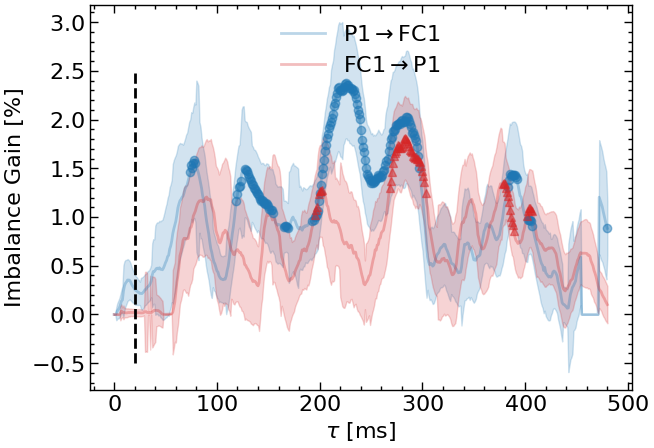

In [27]:
# plot results as a function of tau
fig, ax = plt.subplots(1,1,figsize=(7,5))
ax.plot(taus, IGs_X_to_Y, '-', label=f"{channel_X}$\\rightarrow ${channel_Y}", color="tab:blue", alpha=0.3)
ax.plot(taus, IGs_Y_to_X, '-', label=f"{channel_Y}$\\rightarrow ${channel_X}", color="tab:red", alpha=0.3)
mask_X_to_Y = (IGs_X_to_Y / errors_X_to_Y) > t_99
mask_Y_to_X = (IGs_Y_to_X / errors_Y_to_X) > t_99
ax.plot(taus[mask_X_to_Y], IGs_X_to_Y[mask_X_to_Y], 'o', color="tab:blue", alpha=0.5)
ax.plot(taus[mask_Y_to_X], IGs_Y_to_X[mask_Y_to_X], '^', color="tab:red", alpha=0.5)
ax.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color="tab:blue", alpha=0.2)
ax.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, color="tab:red", alpha=0.2)
ax.vlines(E,-0.5,2.5, linestyle="--", color="black")
ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]")
ax.legend(loc="upper center")
#plt.savefig(f"./figures/IG_channel{channel_X}_vs_channel{channel_Y}.pdf", dpi=300)
plt.show()

# Choice of optimal embedding

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [ ]:
subjects = (['03CM','04ML','05NK','06AT','07YC','08RD','09NT','10EM','11AD','12AD',
             '13AB','14LS','15AC','16AG','17SM','18NB','19LS','20FC','21AB','22RT','23ST'])
channel_X = "P1"
channel_Y = "FC1"
Es = np.arange(1,101)
tau_e = 1
k = 7
t0 = 100
taus = np.arange(0,431)
alphas = np.linspace(0.,1.5,300)

info_imbalances_X_to_Y = np.zeros((len(subjects),len(Es),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(subjects),len(Es),len(alphas)))
for i_sub, sub in enumerate(subjects):
    _, info_imbalances_X_to_Y[i_sub], info_imbalances_Y_to_X[i_sub] = (
        pickle.load(open(f"./pickles_ve_E/II_vs_E_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0}_tauE{tau_e}_k{k}.p","rb"))
    )

# compute Imbalance Gains
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X)

### New channels (19-12-2023), t0 = 50 (0 at offset), E = 50 (half window of baseline correction), k = 7

In [4]:
subjects = (['03CM','04ML','05NK','06AT','07YC','08RD','09NT','10EM','11AD','12AD',
             '13AB','14LS','15AC','16AG','17SM','18NB','19LS','20FC','21AB','22RT','23ST'])
channels_X = ["CP6", "C6"]
channels_Y = ["FCz", "FC2"]
E = 50
tau_e = 1
k = 7
t0 = 50
taus = np.arange(0,451)
alphas = np.linspace(0.,1.5,300)

info_imbalances_X_to_Y = {}
info_imbalances_Y_to_X = {}
IGs_X_to_Y = {}
errors_X_to_Y = {}
IGs_Y_to_X = {}
errors_Y_to_X = {}
for channel_X in channels_X:
    for channel_Y in channels_Y:
        info_imbalances_X_to_Y[channel_X,channel_Y] = np.zeros((len(subjects),len(taus),len(alphas)))
        info_imbalances_Y_to_X[channel_X,channel_Y] = np.zeros((len(subjects),len(taus),len(alphas)))
        np.zeros((len(subjects),len(taus),len(alphas)))
        for i_sub, sub in enumerate(subjects):
            _, info_imbalances_X_to_Y[channel_X,channel_Y][i_sub], info_imbalances_Y_to_X[channel_X,channel_Y][i_sub] = (
                pickle.load(open(f"./pickles/II_sub{sub}_X{channel_X}_Y{channel_Y}_t0{t0}_E{E}_tauE{tau_e}_k{k}.p","rb"))
            )
        # compute Imbalance Gains
        IGs_X_to_Y[channel_X,channel_Y], errors_X_to_Y[channel_X,channel_Y] = compute_IGs(info_imbalances_X_to_Y[channel_X,channel_Y])
        IGs_Y_to_X[channel_X,channel_Y], errors_Y_to_X[channel_X,channel_Y] = compute_IGs(info_imbalances_Y_to_X[channel_X,channel_Y])

In [5]:
# save csv files for Francesca
import pandas as pd

for channel_X in channels_X:
    for channel_Y in channels_Y:
        IGs_allsubj_X_to_Y = 100*((info_imbalances_X_to_Y[channel_X,channel_Y][:,:,0,np.newaxis] - info_imbalances_X_to_Y[channel_X,channel_Y][:,:,:]) 
                        / info_imbalances_X_to_Y[channel_X,channel_Y][:,:,0,np.newaxis])
        IGs_allsubj_Y_to_X = 100*((info_imbalances_Y_to_X[channel_X,channel_Y][:,:,0,np.newaxis] - info_imbalances_Y_to_X[channel_X,channel_Y][:,:,:]) 
                        / info_imbalances_Y_to_X[channel_X,channel_Y][:,:,0,np.newaxis])

        optimal_alphas_X_to_Y = np.argmax(IGs_allsubj_X_to_Y.mean(axis=0), axis=-1)
        optimal_alphas_Y_to_X = np.argmax(IGs_allsubj_Y_to_X.mean(axis=0), axis=-1)

        igs_dataset = []
        taus_dataset = []
        subjects_dataset = []
        for i_sub in range(len(subjects)):
            for j_tau, tau in enumerate(taus):
                igs_dataset.append(IGs_allsubj_X_to_Y[i_sub, j_tau, optimal_alphas_X_to_Y[j_tau]])
                taus_dataset.append(j_tau)
                subjects_dataset.append(i_sub)
        d = {'imbalance_gains': igs_dataset, 'tau_number': taus_dataset, 'subject_number': subjects_dataset}
        df = pd.DataFrame(data=d)
        #df.to_csv(f'./csv_files/{channel_X}_to_{channel_Y}.csv')

        igs_dataset = []
        taus_dataset = []
        subjects_dataset = []
        for i_sub in range(len(subjects)):
            for j_tau, tau in enumerate(taus):
                igs_dataset.append(IGs_allsubj_Y_to_X[i_sub, j_tau, optimal_alphas_Y_to_X[j_tau]])
                taus_dataset.append(j_tau)
                subjects_dataset.append(i_sub)
        d = {'imbalance_gains': igs_dataset, 'tau_number': taus_dataset, 'subject_number': subjects_dataset}
        df = pd.DataFrame(data=d)
        #df.to_csv(f'./csv_files/{channel_Y}_to_{channel_X}.csv')

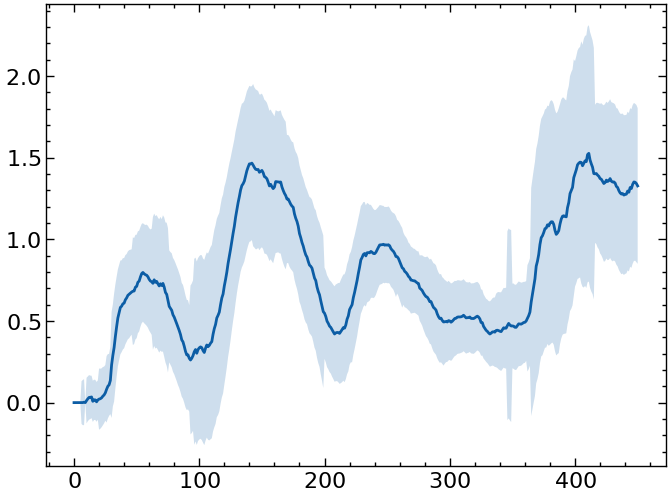

In [23]:
# save csv files for Francesca
'''import pandas as pd

for channel_X in channels_X:
    for channel_Y in channels_Y:
        IGs_allsubj_X_to_Y = 100*((info_imbalances_X_to_Y[channel_X,channel_Y][:,:,0,np.newaxis] - info_imbalances_X_to_Y[channel_X,channel_Y][:,:,:]) 
                        / info_imbalances_X_to_Y[channel_X,channel_Y][:,:,0,np.newaxis])
        IGs_allsubj_Y_to_X = 100*((info_imbalances_Y_to_X[channel_X,channel_Y][:,:,0,np.newaxis] - info_imbalances_Y_to_X[channel_X,channel_Y][:,:,:]) 
                        / info_imbalances_Y_to_X[channel_X,channel_Y][:,:,0,np.newaxis])

        optimal_alphas_X_to_Y = np.argmax(IGs_allsubj_X_to_Y.mean(axis=0), axis=-1)
        optimal_alphas_Y_to_X = np.argmax(IGs_allsubj_Y_to_X.mean(axis=0), axis=-1)

        igs_dataset = []
        taus_dataset = []
        subjects_dataset = []
        for i_sub in range(len(subjects)):
            for j_tau, tau in enumerate(taus):
                igs_dataset.append(IGs_allsubj_X_to_Y[i_sub, j_tau, optimal_alphas_X_to_Y[j_tau]])
                taus_dataset.append(j_tau)
                subjects_dataset.append(i_sub)
        d = {'imbalance_gains': igs_dataset, 'tau_number': taus_dataset, 'subject_number': subjects_dataset}
        df = pd.DataFrame(data=d)
        #df.to_csv(f'./csv_files/{channel_X}_to_{channel_Y}.csv')

        igs_dataset = []
        taus_dataset = []
        subjects_dataset = []
        for i_sub in range(len(subjects)):
            for j_tau, tau in enumerate(taus):
                igs_dataset.append(IGs_allsubj_Y_to_X[i_sub, j_tau, optimal_alphas_Y_to_X[j_tau]])
                taus_dataset.append(j_tau)
                subjects_dataset.append(i_sub)
        d = {'imbalance_gains': igs_dataset, 'tau_number': taus_dataset, 'subject_number': subjects_dataset}
        df = pd.DataFrame(data=d)
        #df.to_csv(f'./csv_files/{channel_Y}_to_{channel_X}.csv')

#... and see if they are correct
channel_X = "CP6"
channel_Y = "FCz"

IGs_X_to_Y = np.zeros((len(subjects),len(taus)))

df_X_to_Y = pd.read_csv(f'./csv_files/{channel_X}_to_{channel_Y}.csv').to_numpy()[:,1:]
for i_sample in range(df_X_to_Y.shape[0]):
    i_tau = int(df_X_to_Y[i_sample,1])
    i_subj = int(df_X_to_Y[i_sample,2])

    IGs_X_to_Y[i_subj,i_tau] = df_X_to_Y[i_sample,0]

plt.plot(taus, IGs_X_to_Y.mean(axis=0))
plt.fill_between(taus, IGs_X_to_Y.mean(axis=0)-IGs_X_to_Y.std(axis=0)/np.sqrt(21),IGs_X_to_Y.mean(axis=0)+IGs_X_to_Y.std(axis=0)/np.sqrt(21), alpha=0.2)
plt.show()'''

/tmp/ipykernel_20010/3000107736.py:7: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
/tmp/ipykernel_20010/3000107736.py:8: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99


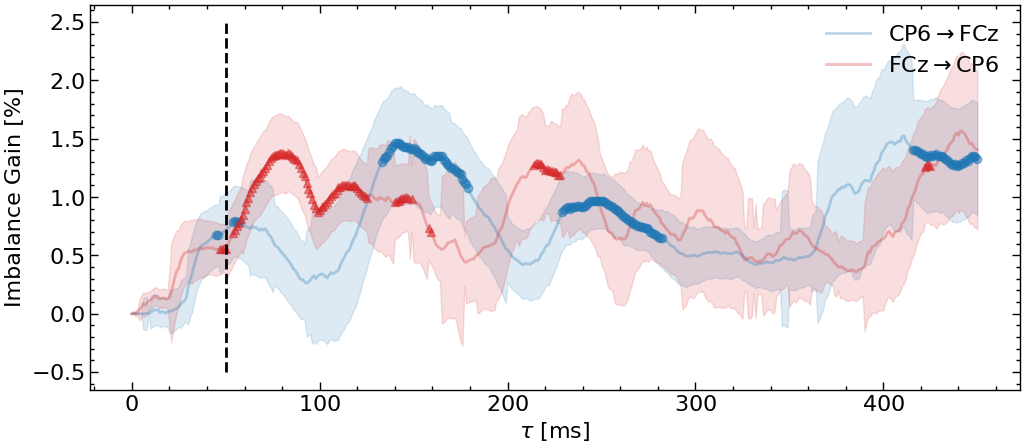

/tmp/ipykernel_20010/3000107736.py:7: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
/tmp/ipykernel_20010/3000107736.py:8: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99


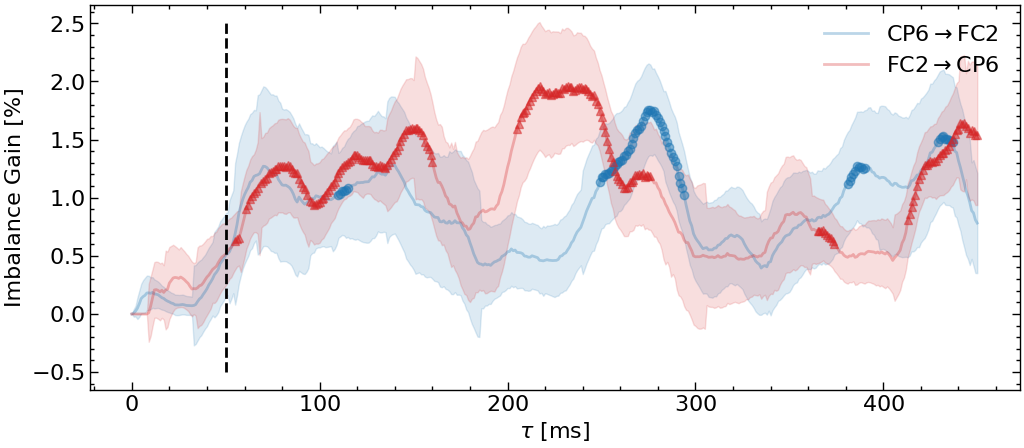

/tmp/ipykernel_20010/3000107736.py:7: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
/tmp/ipykernel_20010/3000107736.py:8: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99


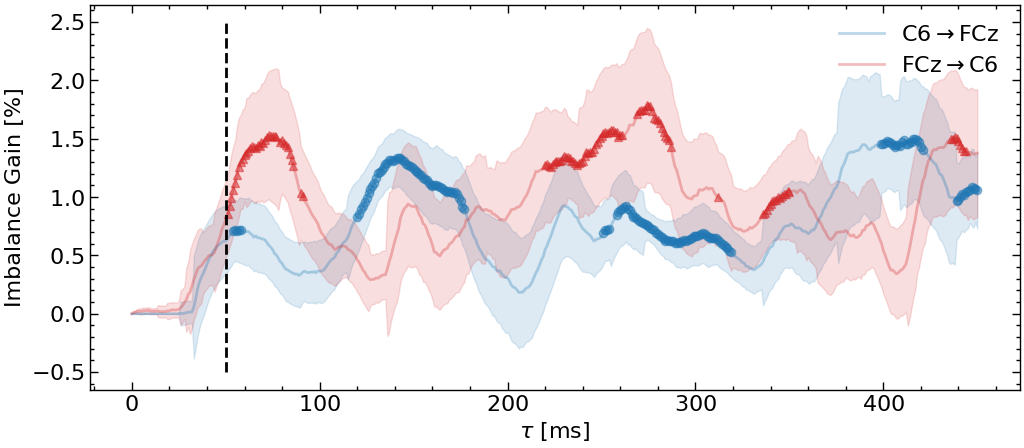

/tmp/ipykernel_20010/3000107736.py:7: RuntimeWarning: invalid value encountered in divide
  mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
/tmp/ipykernel_20010/3000107736.py:8: RuntimeWarning: invalid value encountered in divide
  mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99


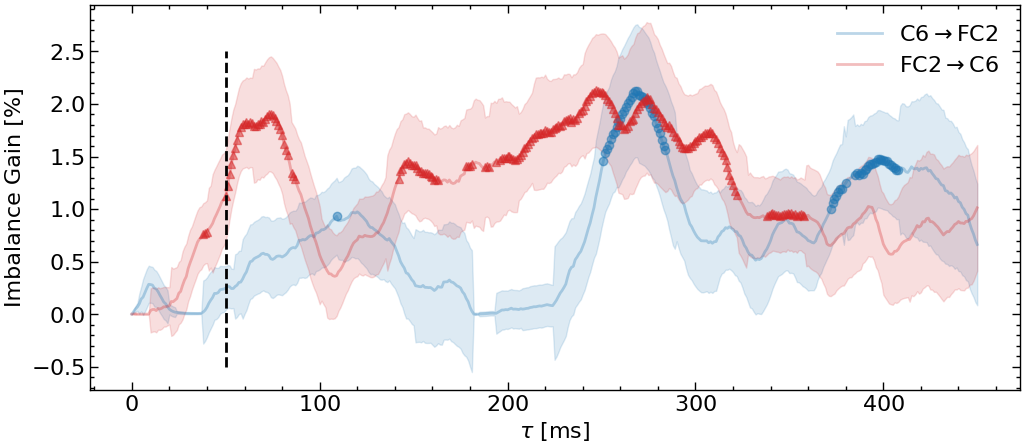

In [16]:
# plot results as a function of tau
for channel_X in channels_X:
    for channel_Y in channels_Y:
        fig, ax = plt.subplots(1,1,figsize=(12,5))
        ax.plot(taus, IGs_X_to_Y[channel_X,channel_Y], '-', label=f"{channel_X}$\\rightarrow ${channel_Y}", color="tab:blue", alpha=0.3)
        ax.plot(taus, IGs_Y_to_X[channel_X,channel_Y], '-', label=f"{channel_Y}$\\rightarrow ${channel_X}", color="tab:red", alpha=0.3)
        mask_X_to_Y = (IGs_X_to_Y[channel_X,channel_Y] / errors_X_to_Y[channel_X,channel_Y]) > t_99
        mask_Y_to_X = (IGs_Y_to_X[channel_X,channel_Y] / errors_Y_to_X[channel_X,channel_Y]) > t_99
        ax.plot(taus[mask_X_to_Y], IGs_X_to_Y[channel_X,channel_Y][mask_X_to_Y], 'o', color="tab:blue", alpha=0.5)
        ax.plot(taus[mask_Y_to_X], IGs_Y_to_X[channel_X,channel_Y][mask_Y_to_X], '^', color="tab:red", alpha=0.5)
        ax.fill_between(taus, IGs_X_to_Y[channel_X,channel_Y]-errors_X_to_Y[channel_X,channel_Y], 
                        IGs_X_to_Y[channel_X,channel_Y]+errors_X_to_Y[channel_X,channel_Y], color="tab:blue", alpha=0.15)
        ax.fill_between(taus, IGs_Y_to_X[channel_X,channel_Y]-errors_Y_to_X[channel_X,channel_Y], 
                        IGs_Y_to_X[channel_X,channel_Y]+errors_Y_to_X[channel_X,channel_Y], color="tab:red", alpha=0.15)
        ax.vlines(E,-0.5,2.5, linestyle="--", color="black")
        ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]")
        ax.legend()#loc="upper center")
        #plt.savefig(f"./figures/IG_channel{channel_X}_vs_channel{channel_Y}.pdf", dpi=300)
        plt.show()